In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from torchvision import transforms
from torchvision.models import resnet18
from torchvision.models import ResNet18_Weights

In [15]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cpu"
)

model = resnet18(
    weights=None
)

model.fc = nn.Linear(
    model.fc.in_features,
    2
)

model.load_state_dict(
    torch.load(
        "pneumonia_resnet18.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [16]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [17]:
image_path = (
    "chest_xray/test/PNEUMONIA/person173_bacteria_829.jpeg"
)

image = Image.open(
    image_path
).convert("L")

input_tensor = transform(
    image
).unsqueeze(0)

input_tensor = input_tensor.to(device)

In [18]:
target_layer = model.layer4[-1].conv2

activations = []
gradients = []

def forward_hook(
    module,
    input,
    output
):
    activations.append(output)

def backward_hook(
    module,
    grad_in,
    grad_out
):
    gradients.append(
        grad_out[0]
    )

forward_handle = (
    target_layer.register_forward_hook(
        forward_hook
    )
)

backward_handle = (
    target_layer.register_full_backward_hook(
        backward_hook
    )
)

In [19]:
output = model(
    input_tensor
)

prediction = output.argmax(
    dim=1
)

print(
    "Prediction:",
    prediction.item()
)

model.zero_grad()

score = output[
    0,
    prediction
]

score.backward()

Prediction: 1


In [20]:
activation = (
    activations[0]
    .detach()
    .cpu()
)

gradient = (
    gradients[0]
    .detach()
    .cpu()
)

weights = gradient.mean(
    dim=(2,3),
    keepdim=True
)

cam = (
    weights *
    activation
).sum(
    dim=1
).squeeze()

cam = torch.relu(
    cam
)

cam -= cam.min()

cam /= (
    cam.max() + 1e-8
)

cam = cam.numpy()

In [21]:
from PIL import Image

cam_image = Image.fromarray(
    np.uint8(
        cam * 255
    )
)

cam_image = cam_image.resize(
    image.size
)

cam = np.array(
    cam_image
) / 255

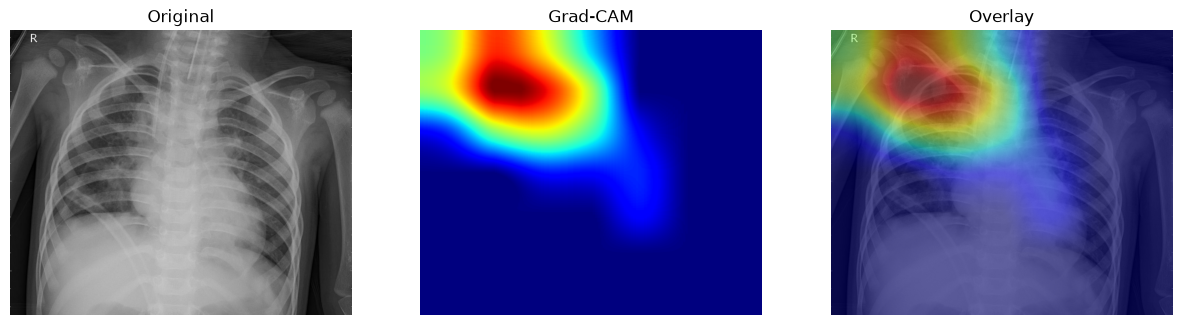

In [22]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15,5)
)

axes[0].imshow(
    image,
    cmap="gray"
)

axes[0].set_title(
    "Original"
)

axes[0].axis("off")

axes[1].imshow(
    cam,
    cmap="jet"
)

axes[1].set_title(
    "Grad-CAM"
)

axes[1].axis("off")

axes[2].imshow(
    image,
    cmap="gray"
)

axes[2].imshow(
    cam,
    cmap="jet",
    alpha=0.5
)

axes[2].set_title(
    "Overlay"
)

axes[2].axis("off")

plt.show()

In [23]:
forward_handle.remove()
backward_handle.remove()